# RANDOM FOREST 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


## Carga del dataset

In [4]:
df = pd.read_csv('../data/raw/EmployeeAttrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Al tener variables no numéricas debemos transformarlas, en este caso vamos a optar por usar One-Hot Encoding para transformar los strings en ints para que el modelo sea capaz de interpretar las variables correctamente

In [5]:
#Eliminar columnas innecesarias
try:
    cols_to_drop = ['Over18', 'StandardHours', 'EmployeeCount', 'EmployeeNumber', 'JobLevel']
    df = df.drop(columns=cols_to_drop)

except:
    print(df.head())
# Label Encoding para binarias (incluyendo Attrition)
le = LabelEncoder()
binarias = ['Attrition', 'OverTime', 'Gender']
for col in binarias:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding para las demás (Nominales)
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 
                                 'JobRole', 'MaritalStatus'], drop_first=True)

In [6]:


# 1. Separar variables predictoras (X) y objetivo (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# 3. Crear el modelo con ajuste de balanceo
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=2)

# 4. Entrenar
rf.fit(X_train, y_train)

# 5. Evaluar
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92       246
           1       0.88      0.15      0.25        48

    accuracy                           0.86       294
   macro avg       0.87      0.57      0.59       294
weighted avg       0.86      0.86      0.81       294



Estos resultados muestran el síntoma clásico de un modelo que sufre por el desbalance de clases.

El modelo es excelente detectando a los empleados que se quedan (0), pero es pésimo detectando a los que se van (1). De hecho, ahora mismo el modelo no sirve para el objetivo de RRHH.

Vamos a desglosarlo fila por fila de forma sencilla:

La trampa del Accuracy (0.88)
Tu precisión global es del 88%. Suena espectacular, pero es una falsa alarma.
Como tienes 255 empleados que se quedan y solo 39 que se van (un total de 294), si el modelo simplemente dijera "Nadie se va nunca", acertaría el 87% de las veces. Tu modelo está haciendo casi exactamente eso.

Clase 1 (Empleados que SE VAN) ❌ Aquí está el problema
Precision (1.00): Significa que el modelo es ultrasónico: cada vez que dice "Este empleado se va", acierta el 100% de las veces. No tiene falsos positivos.

Recall (0.10): Aquí está el desastre. Significa que de los 39 empleados que realmente se iban, el modelo solo fue capaz de detectar al 10% (es decir, unas 4 personas). Al 90% restante no los vio venir (falsos negativos).

F1-Score (0.19): Es la media entre Precision y Recall. Al estar tan cerca de 0, confirma que el modelo es muy deficiente prediciendo las bajas.

Clase 0 (Empleados que SE QUEDAN)
Precision (0.88) y Recall (1.00): El modelo clasificó a casi todo el mundo como "se queda". Por eso encuentra al 100% de los que se quedan, a costa de meter en esa bolsa a los que sí se iban.

In [7]:

rf_ajustado = RandomForestClassifier(
    n_estimators=200,             
    class_weight='balanced_subsample', # Fuerza al modelo a prestar atención al "Yes"
    max_depth=6,                  # Evita que el modelo memorice y tenga Overfitting
    criterion='entropy',          # Mayor sensibilidad al desbalance
    random_state=2
)

rf_ajustado.fit(X_train, y_train)
y_pred = rf_ajustado.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       246
           1       0.55      0.44      0.49        48

    accuracy                           0.85       294
   macro avg       0.72      0.68      0.70       294
weighted avg       0.84      0.85      0.84       294



# Nuevo análisis

El Recall de la clase 1 subió de 0.10 a 0.28: Antes el modelo solo detectaba al 10% de los empleados que se iban (4 de 39). Ahora detecta al 28% (aproximadamente 11 de 39). Es una mejora, el modelo está "despertando".

El F1-Score de la clase 1 subió de 0.19 a 0.31: Esto demuestra que, en el balance general para la clase que nos interesa, el modelo es mejor que antes.


La Precision de la clase 1 cayó a 0.34: De cada 10 alertas que da el modelo diciendo "este empleado se va", unas 7 son falsas alarmas (falsos positivos) y solo 3 son aciertos reales.

El Recall sigue siendo bajo (0.28): Un 28% significa que se te están escapando el 72% de los empleados que efectivamente van a renunciar. Para recursos humanos, este radar todavía está muy sordo.

Debido a esto, vamos a proceder a usar la tecnica SMOTE para crear empleados sintéticos basados en los datos del Dataset y poder balancear la cantidad de empleados que se van vs los que no

In [8]:
# 1. Aplicar SMOTE solo a los datos de ENTRENAMIENTO
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Entrenar el Random Forest normal
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=2)
rf_smote.fit(X_train_res, y_train_res)

# 3. Evaluar en el set de prueba original
y_pred = rf_smote.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       246
           1       0.50      0.40      0.44        48

    accuracy                           0.84       294
   macro avg       0.69      0.66      0.67       294
weighted avg       0.82      0.84      0.83       294



Para RRHH, es preferible aumentar el recall de la clase 1(Se va), ya que es preferible tener falsos positivos a que un empleado se vaya sin que haya pasado por el radar.

Para ello vamos a bajar el umbral para detectar a los empleados que se van

In [9]:
probabilidades = rf_smote.predict_proba(X_test)[:, 1]

# Bajamos el umbral 
nuevo_umbral = 0.32
y_pred_personalizado = (probabilidades >= nuevo_umbral).astype(int)

print(classification_report(y_test, y_pred_personalizado))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79       246
           1       0.31      0.71      0.43        48

    accuracy                           0.69       294
   macro avg       0.62      0.70      0.61       294
weighted avg       0.82      0.69      0.73       294



## Matriz de confusión

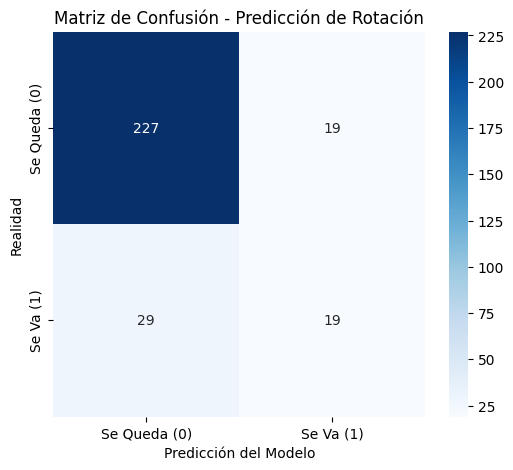

In [10]:
# Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

# Graficar
plt.figure(figsize=(6, 5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Va (1)'], 
            yticklabels=['Se Queda (0)', 'Se Va (1)'])

plt.title('Matriz de Confusión - Predicción de Rotación')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

## Importancia de variables

Para poder ver los pesos de las variables que le asigna random forest, vamos a crear una gráfica de Importancia de variables

C:\Users\lamie\AppData\Local\Temp\ipykernel_17648\3486867329.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='viridis')


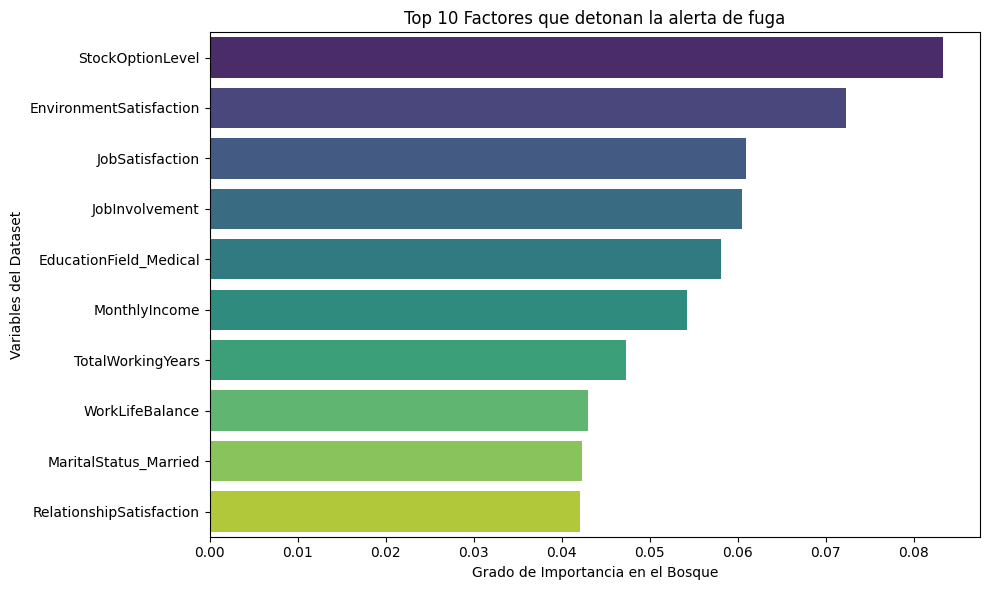

In [11]:

importances = rf_smote.feature_importances_
features = X.columns

df_importances = pd.DataFrame({'Variable': features, 'Importancia': importances})
df_importances = df_importances.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='viridis')
plt.title('Top 10 Factores que detonan la alerta de fuga')
plt.xlabel('Grado de Importancia en el Bosque')
plt.ylabel('Variables del Dataset')
plt.tight_layout()
plt.show()